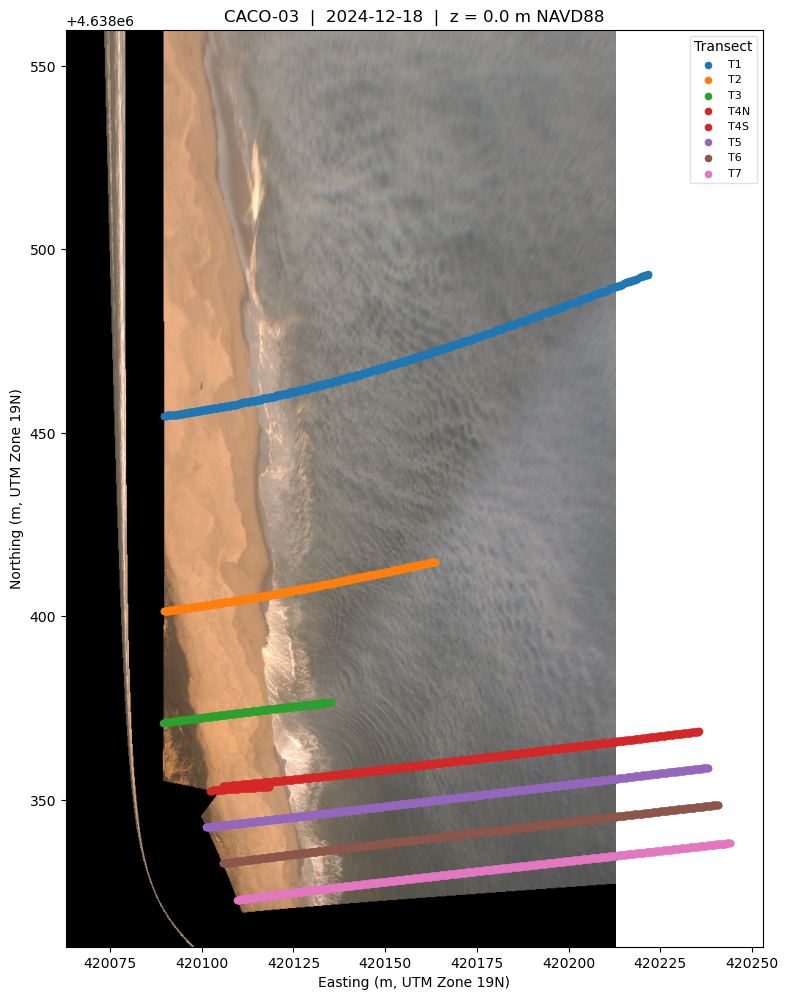

In [1]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
import numpy as np
import matplotlib.pyplot as plt
import yaml
import rioxarray
import string
from PIL import Image

# ── utils_CIRN functions ───────────────────────────────────────────────────────
%run -i F:\crs\src\ShoreScan\runup\CODES\utils_CIRN.py

# ── Configuration ─────────────────────────────────────────────────────────────
CAL_DIR  = r"F:\crs\proj\marconi_imagery\calibration_parameters"
PIX_DIR  = r"F:\crs\proj\marconi_imagery\pixel_locations"

IO_C1 = CAL_DIR + r"\CACO03_c1_20240801_IO.yaml"
IO_C2 = CAL_DIR + r"\CACO03_c2_20240801_IO.yaml"
EO_C1 = CAL_DIR + r"\CACO03_c1_20241023_EO.yaml"
EO_C2 = CAL_DIR + r"\CACO03_c2_20241023_EO.yaml"

C1_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c1\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c1.snap.jpg"
C2_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c2\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c2.snap.jpg"
C1_PIX = PIX_DIR + r"\c1_timestack.pix"
C2_PIX = PIX_DIR + r"\c2_timestack.pix"

GRID_RES     = 0.2
CAM_X        = 420088.0
CAM_Y        = 4638320.0
x_min, x_max = CAM_X - 25.0, CAM_X + 125.0
y_min, y_max = CAM_Y - 10.0, CAM_Y + 240.0

Z_PLANES     = [0.0, 1.0, 2.0]   # m NAVD88
Z_PLANE_PLOT = 0.0
GAP_FACTOR   = 10.0

# ── Named transect definitions (north to south) ───────────────────────────────
# (display name, camera, raw tid from get_transect_ids)
# C1 tids 0,1,2 are ignored (too far seaward / outside analysis area)
TRANSECT_DEFS = [
    ('T1',  'c2', 0),
    ('T2',  'c2', 1),
    ('T3',  'c2', 2),
    ('T4N', 'c2', 3),
    ('T4S', 'c1', 3),
    ('T5',  'c1', 4),
    ('T6',  'c1', 5),
    ('T7',  'c1', 6),
]

# Tab10 color index per transect (T4N and T4S share a color)
TRANSECT_COLOR_IDX = {
    'T1': 0, 'T2': 1, 'T3': 2,
    'T4N': 3, 'T4S': 3,
    'T5': 4, 'T6': 5, 'T7': 6,
}

def tab_color(i):
    return plt.colormaps['tab10'](i / 9)

# ── Load calibrations ─────────────────────────────────────────────────────────
def load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)

io1, io2 = load_yaml(IO_C1), load_yaml(IO_C2)
eo1, eo2 = load_yaml(EO_C1), load_yaml(EO_C2)

# ── Rectification grid ────────────────────────────────────────────────────────
xs = np.arange(x_min, x_max, GRID_RES)
ys = np.arange(y_min, y_max, GRID_RES)
Xg, Yg  = np.meshgrid(xs, ys)
Zg       = np.full_like(Xg, Z_PLANE_PLOT)
xyz_grid = np.column_stack((Xg.ravel(), Yg.ravel(), Zg.ravel()))

def project_grid(xyz, io, eo):
    UVd, flag = xyz_to_dist_uv(io, eo, xyz)
    Ud   = UVd[0].reshape(Xg.shape)
    Vd   = UVd[1].reshape(Xg.shape)
    flag = flag.reshape(Xg.shape)
    valid = (flag == 1) & (Ud >= 0) & (Ud < io['NU']) & (Vd >= 0) & (Vd < io['NV'])
    Ud[~valid] = np.nan
    Vd[~valid] = np.nan
    return Ud, Vd

Ud1, Vd1 = project_grid(xyz_grid, io1, eo1)
Ud2, Vd2 = project_grid(xyz_grid, io2, eo2)

def sample_image(img_path, Ud, Vd):
    img  = np.array(Image.open(img_path))
    h, w = img.shape[:2]
    Ir   = np.zeros((*Ud.shape, 3), dtype=np.uint8)
    valid = ~np.isnan(Ud) & ~np.isnan(Vd)
    ui = np.where(valid, Ud, 0).astype(int).clip(0, w - 1)
    vi = np.where(valid, Vd, 0).astype(int).clip(0, h - 1)
    Ir[valid] = img[vi[valid], ui[valid]]
    return Ir, valid

Ir1, valid1  = sample_image(C1_IMG, Ud1, Vd1)
Ir2, valid2  = sample_image(C2_IMG, Ud2, Vd2)
IrIndv       = np.stack([Ir1, Ir2], axis=-1).astype(float)
Ir_merged    = camera_seam_blend(IrIndv)

# ── Transect detection ────────────────────────────────────────────────────────
def get_transect_ids(uv, gap_factor=GAP_FACTOR):
    dists     = np.linalg.norm(np.diff(uv, axis=0), axis=1)
    threshold = np.median(dists) * gap_factor
    breaks    = np.where(dists > threshold)[0] + 1
    ids       = np.zeros(len(uv), dtype=int)
    for seg_id, start in enumerate(breaks):
        ids[start:] = seg_id + 1
    return ids

c1_uv  = np.loadtxt(C1_PIX)
c2_uv  = np.loadtxt(C2_PIX)
c1_ids = get_transect_ids(c1_uv)   # raw 0-based: 0..6
c2_ids = get_transect_ids(c2_uv)   # raw 0-based: 0..3

# ── Project named transects to world coords at each Z_PLANE ──────────────────
# xyz_named[name][z] = Nx3 array (E, N, z_assumed)
xyz_named = {}
for name, cam, raw_tid in TRANSECT_DEFS:
    xyz_named[name] = {}
    if cam == 'c1':
        ids_arr, uv_arr, io, eo = c1_ids, c1_uv, io1, eo1
    else:
        ids_arr, uv_arr, io, eo = c2_ids, c2_uv, io2, eo2
    mask = (ids_arr == raw_tid)
    uv_t = uv_arr[mask]
    for z in Z_PLANES:
        xyz_named[name][z] = dist_uv_to_xyz(io, eo,
                                             uv_t[:, 0], uv_t[:, 1], 'z', z)

# ── Plot rectified image with named transects ─────────────────────────────────
extent = [xs[0], xs[-1], ys[0], ys[-1]]

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(Ir_merged, origin='lower', extent=extent, aspect='equal')

for name, cam, raw_tid in TRANSECT_DEFS:
    xyz  = xyz_named[name][Z_PLANE_PLOT]
    cidx = TRANSECT_COLOR_IDX[name]
    ax.scatter(xyz[:, 0], xyz[:, 1],
               color=tab_color(cidx), s=20, zorder=5, label=name)

ax.set_xlabel('Easting (m, UTM Zone 19N)')
ax.set_ylabel('Northing (m, UTM Zone 19N)')
ax.set_title(f'CACO-03  |  2024-12-18  |  z = {Z_PLANE_PLOT} m NAVD88')
ax.legend(loc='upper right', fontsize=8, framealpha=0.6, title='Transect')
plt.tight_layout()
plt.savefig('rectified_merged_transects.png', dpi=150, bbox_inches='tight')
plt.show()

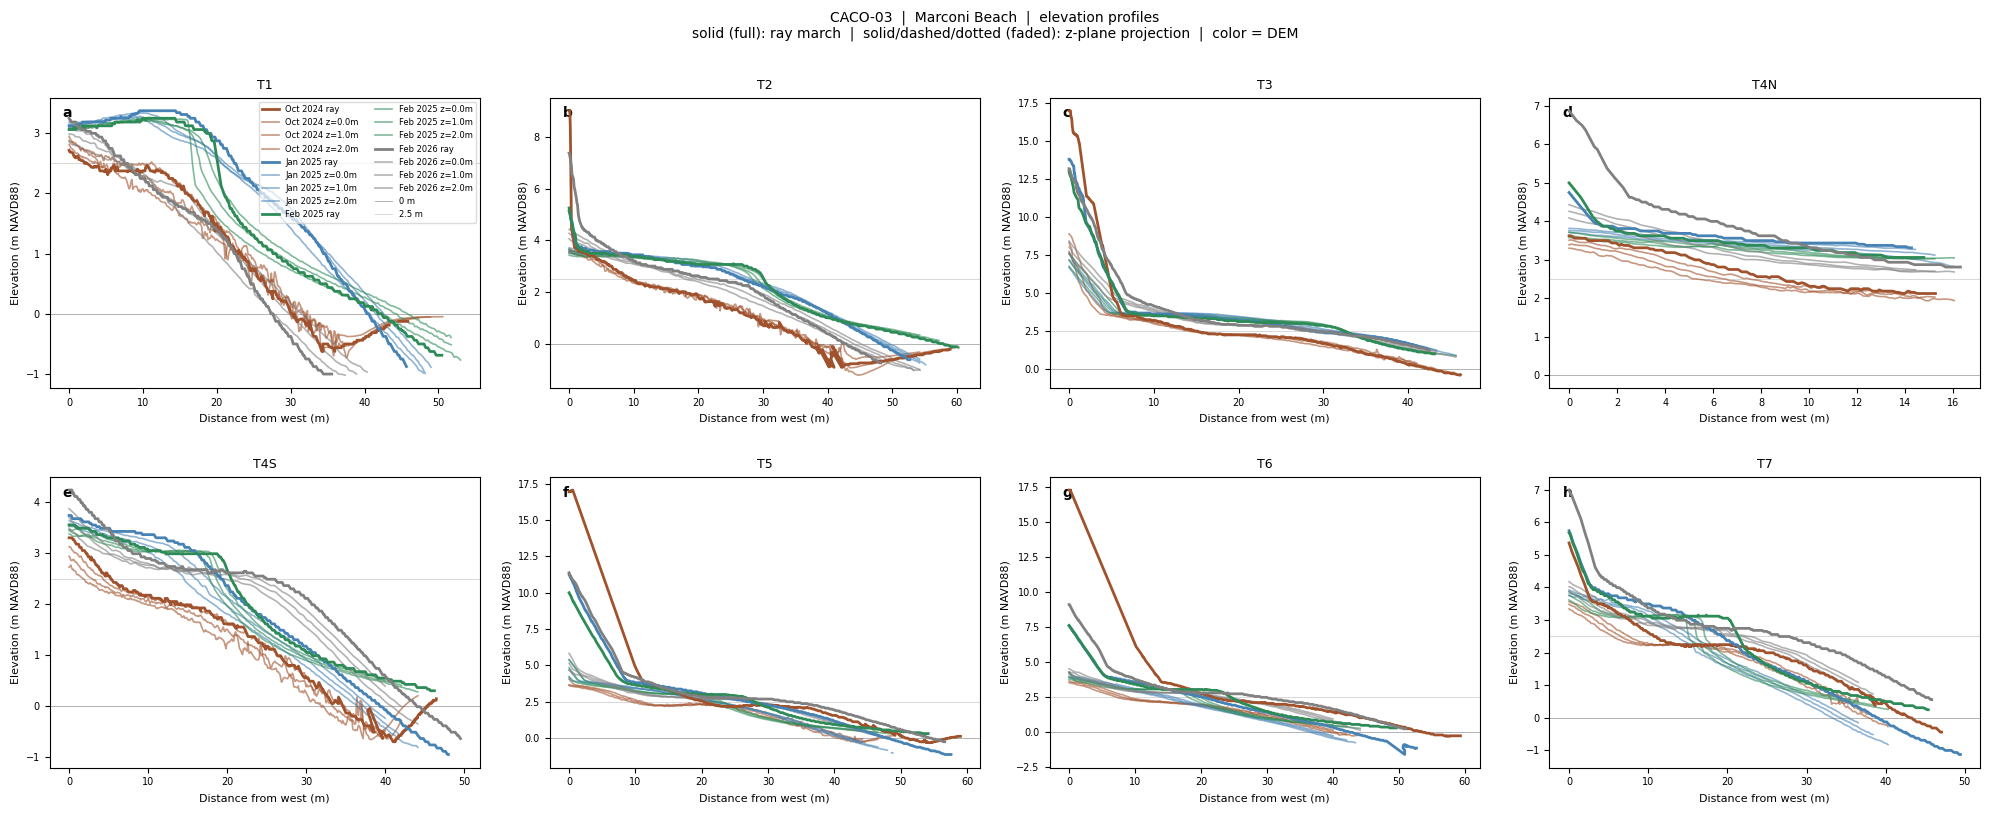

In [2]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
# Elevation profiles: ray-marching (solid) + z-plane projections (alpha=0.6)
# One panel per transect; color = DEM, linestyle = z-plane

import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import string
from scipy.interpolate import RegularGridInterpolator

# ── DEM list ──────────────────────────────────────────────────────────────────
DEM_file_list = [
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2024_Oct_Marconi_DSM_camera_5cm_cog.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2025-005-FA_Marconi_Jan_YSMP_DSM_25cm.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2025-005-FA_Mar_Marconi_YSMP_DSM_25cm.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2026007FA_03-19-2026_Marconi_W1LDR_DSM_50cm_UTM19N_NAVD88.tif",
]
DEM_file_names = ['Oct 2024', 'Jan 2025', 'Feb 2025', 'Feb 2026']
DEM_colors     = ['sienna', 'steelblue', 'seagreen', 'gray']

EASTING_MAX  = 420150.0
Z_STYLES     = {0.0: '-', 1.0: '-', 2.0: '-'}
panel_labels = string.ascii_lowercase

# ── Build DEM interpolators ───────────────────────────────────────────────────
def build_interp(path):
    dem = rioxarray.open_rasterio(path, masked=True).squeeze()
    x   = dem.x.values
    y   = dem.y.values
    z   = dem.values
    if y[0] > y[-1]:
        y, z = y[::-1], z[::-1, :]
    return RegularGridInterpolator((y, x), z, method='linear',
                                   bounds_error=False, fill_value=np.nan)

interp_list = [build_interp(p) for p in DEM_file_list]

# ── Build sens_named (z-plane projected E/N, DEM-sampled Z) ──────────────────
sens_named = {}
for name, cam, raw_tid in TRANSECT_DEFS:
    xyz0  = xyz_named[name][Z_PLANES[0]]
    emask = xyz0[:, 0] <= EASTING_MAX
    npts  = emask.sum()
    if npts < 2:
        continue
    E_arr = np.full((npts, len(Z_PLANES)), np.nan)
    N_arr = np.full((npts, len(Z_PLANES)), np.nan)
    Z_arr = np.full((npts, len(Z_PLANES), len(interp_list)), np.nan)
    for z_idx, z in enumerate(Z_PLANES):
        pts = xyz_named[name][z][emask]
        E_arr[:, z_idx] = pts[:, 0]
        N_arr[:, z_idx] = pts[:, 1]
        for d_idx, interp in enumerate(interp_list):
            Z_arr[:, z_idx, d_idx] = interp((pts[:, 1], pts[:, 0]))
    sens_named[name] = {'E': E_arr, 'N': N_arr, 'Z': Z_arr}

# ── Ray-march each transect against each DEM ─────────────────────────────────
# ray_named[name][d_idx] = {'dist', 'Z'}
def get_cam_origin(cam):
    eo = eo1 if cam == 'c1' else eo2
    return np.array([eo['x'], eo['y'], eo['z']])

ray_named = {name: {} for name in sens_named}
dem_xarrays = [rioxarray.open_rasterio(p, masked=True).squeeze()
               for p in DEM_file_list]

for name, cam, raw_tid in TRANSECT_DEFS:
    if name not in sens_named:
        continue
    t             = sens_named[name]
    E_z0          = t['E'][:, 0]
    N_z0          = t['N'][:, 0]
    xyz_in        = np.column_stack((E_z0, N_z0, np.zeros(len(E_z0))))
    transect_data = {'xyz': xyz_in}
    camera_origin = get_cam_origin(cam)

    for d_idx, dem_xa in enumerate(dem_xarrays):
        interp_func  = get_interp_dem(dem_xa)
        xyz_pts, _   = get_elevation_from_dem(interp_func, transect_data,
                                               camera_origin,
                                               initial_step_size=-0.5,
                                               max_steps=500, max_error=0.05)
        E_ray = xyz_pts[:, 0]
        Z_ray = xyz_pts[:, 2]
        dist  = E_ray - np.nanmin(E_ray)
        ray_named[name][d_idx] = {'dist': dist, 'Z': Z_ray}

# ── Plot ──────────────────────────────────────────────────────────────────────
plot_names = [t[0] for t in TRANSECT_DEFS if t[0] in sens_named]
N_PLOT     = len(plot_names)
ncols      = 4
nrows      = int(np.ceil(N_PLOT / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = axes.ravel()

for idx, name in enumerate(plot_names):
    ax = axes[idx]
    t  = sens_named[name]

    for d_idx, (dname, dcol) in enumerate(zip(DEM_file_names, DEM_colors)):

        # Ray-march profile — solid, full opacity, thicker
        if d_idx in ray_named[name]:
            r   = ray_named[name][d_idx]
            lbl = f'{dname} ray' if idx == 0 else None
            ax.plot(r['dist'], r['Z'], color=dcol, ls='-', lw=2.0,
                    alpha=1.0, zorder=5, label=lbl)

        # z-plane profiles — same color, faded, linestyle encodes z-plane
        for z_idx, z in enumerate(Z_PLANES):
            E    = t['E'][:, z_idx]
            dist = E - np.nanmin(E)
            elev = t['Z'][:, z_idx, d_idx]
            lbl  = f'{dname} z={z}m' if idx == 0 else None
            ax.plot(dist, elev, color=dcol, ls=Z_STYLES[z], lw=1.2,
                    alpha=0.6, zorder=4, label=lbl)

    ax.axhline(0,   color='k',    lw=0.7, ls='-',  alpha=0.3,
               label='0 m'   if idx == 0 else None)
    ax.axhline(2.5, color='gray', lw=0.7, ls='-', alpha=0.3,
               label='2.5 m' if idx == 0 else None)
    ax.set_xlabel('Distance from west (m)', fontsize=8)
    ax.set_ylabel('Elevation (m NAVD88)',   fontsize=8)
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.text(0.03, 0.97, panel_labels[idx],
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

axes[0].legend(fontsize=6, framealpha=0.7, ncol=2)
for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle('CACO-03  |  Marconi Beach  |  elevation profiles\n'
             'solid (full): ray march  |  solid/dashed/dotted (faded): z-plane projection  |  color = DEM',
             fontsize=10, y=1.01)
plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig('named_transect_profiles_raymarch.png', dpi=150, bbox_inches='tight')
plt.show()

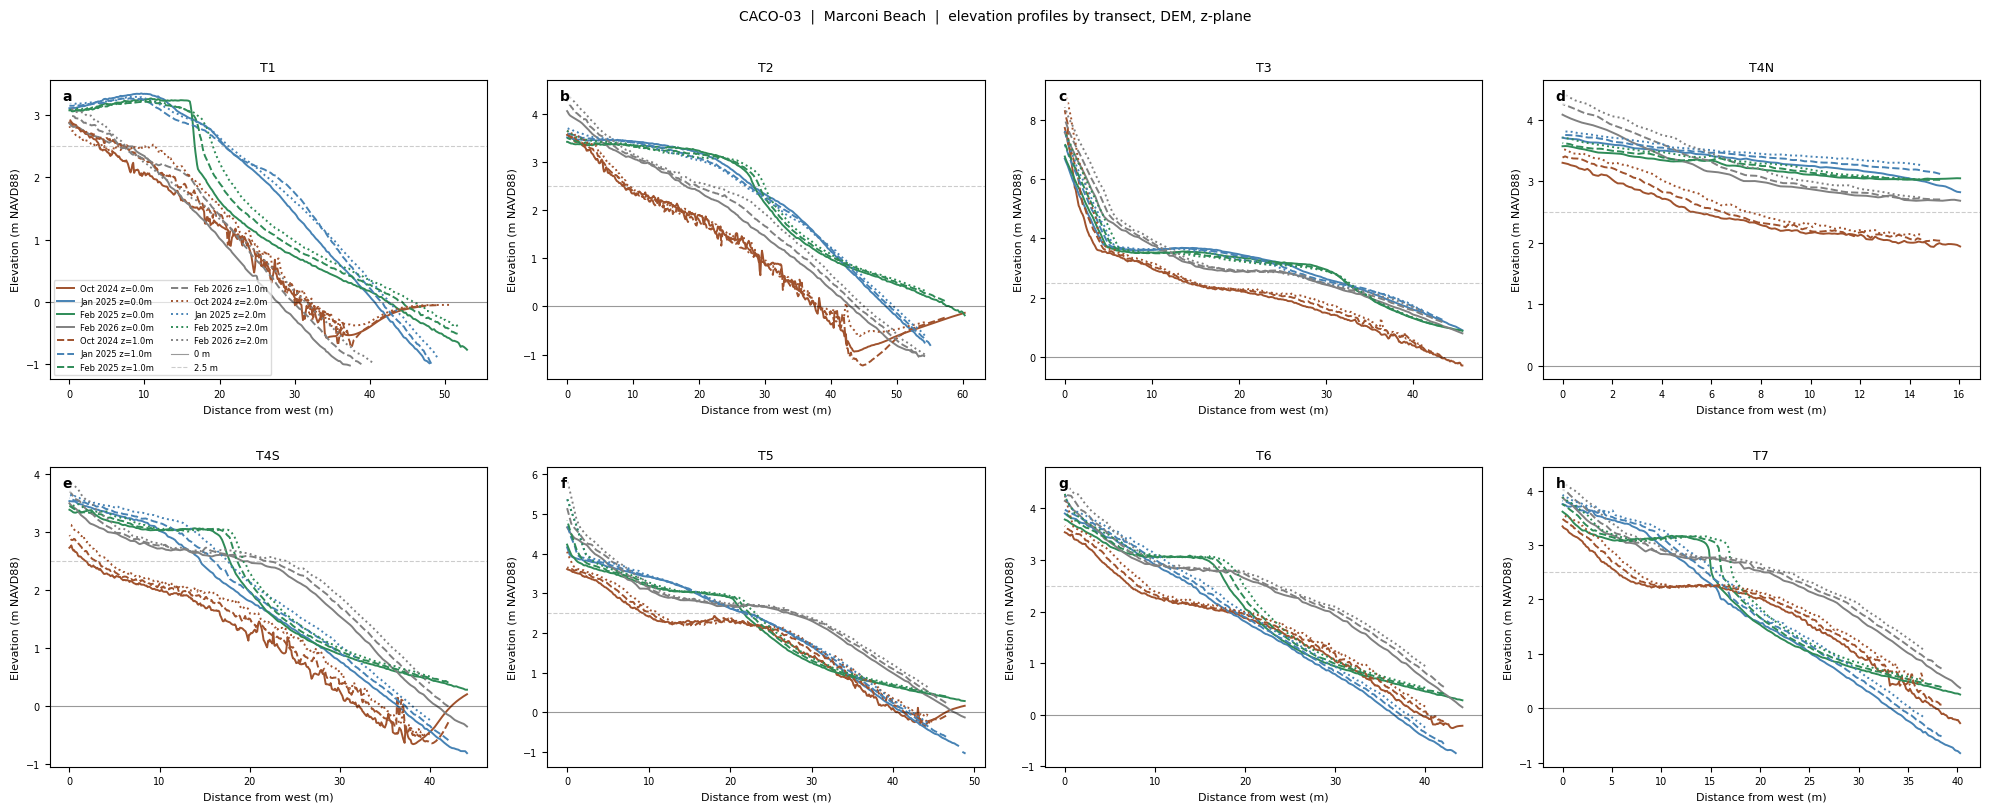

In [3]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import string
from scipy.interpolate import RegularGridInterpolator

# ── DEM list ──────────────────────────────────────────────────────────────────
DEM_file_list = [
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2024_Oct_Marconi_DSM_camera_5cm_cog.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2025-005-FA_Marconi_Jan_YSMP_DSM_25cm.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2025-005-FA_Mar_Marconi_YSMP_DSM_25cm.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2026007FA_03-19-2026_Marconi_W1LDR_DSM_50cm_UTM19N_NAVD88.tif",
]
DEM_file_names = ['Oct 2024', 'Jan 2025', 'Feb 2025', 'Feb 2026']
DEM_colors     = ['sienna', 'steelblue', 'seagreen', 'gray']

EASTING_MAX  = 420150.0
Z_STYLES     = {0.0: '-', 1.0: '--', 2.0: ':'}
panel_labels = string.ascii_lowercase

# ── Build DEM interpolators ───────────────────────────────────────────────────
def build_interp(path):
    dem = rioxarray.open_rasterio(path, masked=True).squeeze()
    x   = dem.x.values
    y   = dem.y.values
    z   = dem.values
    if y[0] > y[-1]:
        y, z = y[::-1], z[::-1, :]
    return RegularGridInterpolator((y, x), z, method='linear',
                                   bounds_error=False, fill_value=np.nan)

interp_list = [build_interp(p) for p in DEM_file_list]

# ── Build sens_named ──────────────────────────────────────────────────────────
# sens_named[name]['E'] : (Npts, N_z)
# sens_named[name]['N'] : (Npts, N_z)
# sens_named[name]['Z'] : (Npts, N_z, N_dem)
sens_named = {}
for name, cam, raw_tid in TRANSECT_DEFS:
    xyz0  = xyz_named[name][Z_PLANES[0]]
    emask = xyz0[:, 0] <= EASTING_MAX
    npts  = emask.sum()
    if npts < 2:
        continue
    E_arr = np.full((npts, len(Z_PLANES)), np.nan)
    N_arr = np.full((npts, len(Z_PLANES)), np.nan)
    Z_arr = np.full((npts, len(Z_PLANES), len(interp_list)), np.nan)
    for z_idx, z in enumerate(Z_PLANES):
        pts = xyz_named[name][z][emask]
        E_arr[:, z_idx] = pts[:, 0]
        N_arr[:, z_idx] = pts[:, 1]
        for d_idx, interp in enumerate(interp_list):
            Z_arr[:, z_idx, d_idx] = interp((pts[:, 1], pts[:, 0]))
    sens_named[name] = {
        'E': E_arr, 'N': N_arr, 'Z': Z_arr,
        'z_planes': Z_PLANES, 'dem_names': DEM_file_names,
    }

# ── Elevation profiles ────────────────────────────────────────────────────────
plot_names = [t[0] for t in TRANSECT_DEFS if t[0] in sens_named]
N_PLOT     = len(plot_names)
ncols      = 4
nrows      = int(np.ceil(N_PLOT / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = axes.ravel()

for idx, name in enumerate(plot_names):
    ax = axes[idx]
    t  = sens_named[name]

    for z_idx, z in enumerate(Z_PLANES):
        E    = t['E'][:, z_idx]
        dist = E - np.nanmin(E)
        for d_idx, (dname, dcol) in enumerate(zip(DEM_file_names, DEM_colors)):
            elev = t['Z'][:, z_idx, d_idx]
            lbl  = f'{dname} z={z}m' if idx == 0 else None
            ax.plot(dist, elev, color=dcol, ls=Z_STYLES[z], lw=1.4, label=lbl)

    ax.axhline(0,   color='k',    lw=0.8, ls='-',  alpha=0.4,
               label='0 m'   if idx == 0 else None)
    ax.axhline(2.5, color='gray', lw=0.8, ls='--', alpha=0.4,
               label='2.5 m' if idx == 0 else None)
    ax.set_xlabel('Distance from west (m)', fontsize=8)
    ax.set_ylabel('Elevation (m NAVD88)',   fontsize=8)
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.text(0.03, 0.97, panel_labels[idx],
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

axes[0].legend(fontsize=6, framealpha=0.7, ncol=2)
for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle('CACO-03  |  Marconi Beach  |  elevation profiles by transect, DEM, z-plane',
             fontsize=10, y=1.01)
plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig('named_transect_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
# Runup horizontal excursion sensitivity to z-plane assumption
# Update WINDOWS after inspecting profiles in cell 2

import numpy as np

# ── Distance windows (easting-based dist from westernmost point) ──────────────
# Update these after inspecting the profiles
WINDOWS = {
    'T1' : (20, 35),   # placeholder
    'T2' : (10, 40),   # placeholder
    'T3' : (10, 40),   # placeholder
    'T4N': ( 5, 15),   # placeholder
    'T4S': (10, 35),   # placeholder
    'T5' : (22, 40),   # placeholder
    'T6' : (20, 40),   # placeholder
    'T7' : (15, 35),   # placeholder
}

print(f"{'Transect':>10}  {'z-plane':>8}  {'E_start':>10}  {'N_start':>10}  "
      f"{'E_end':>10}  {'N_end':>10}  {'dE (m)':>8}  {'dN (m)':>8}  "
      f"{'dr (m)':>8}  {'frac var':>10}")
print("-" * 112)

for name in [t[0] for t in TRANSECT_DEFS]:
    if name not in sens_named or name not in WINDOWS:
        continue
    t = sens_named[name]
    d_lo, d_hi = WINDOWS[name]

    E_z0    = t['E'][:, 0]
    dist_z0 = E_z0 - np.nanmin(E_z0)
    i_start = np.nanargmin(np.abs(dist_z0 - d_lo))
    i_end   = np.nanargmin(np.abs(dist_z0 - d_hi))

    dr_vals, rows = [], []
    for z_idx, z in enumerate(Z_PLANES):
        E  = t['E'][:, z_idx]
        N  = t['N'][:, z_idx]
        E0, N0 = E[i_start], N[i_start]
        E1, N1 = E[i_end],   N[i_end]
        dE = E1 - E0
        dN = N1 - N0
        dr = np.sqrt(dE**2 + dN**2)
        dr_vals.append(dr)
        rows.append((z, E0, N0, E1, N1, dE, dN, dr))

    dr_mean  = np.mean(dr_vals)
    frac_var = (max(dr_vals) - min(dr_vals)) / dr_mean

    for i, (z, E0, N0, E1, N1, dE, dN, dr) in enumerate(rows):
        frac_str = f'{frac_var:.3f}' if i == 1 else ''
        print(f"{name:>10}  {z:>8.1f}  {E0:>10.2f}  {N0:>10.2f}  "
              f"{E1:>10.2f}  {N1:>10.2f}  {dE:>8.3f}  {dN:>8.3f}  "
              f"{dr:>8.3f}  {frac_str:>10}")
    print()

  Transect   z-plane     E_start     N_start       E_end       N_end    dE (m)    dN (m)    dr (m)    frac var
----------------------------------------------------------------------------------------------------------------
        T1       0.0   420109.63  4638458.00   420124.70  4638461.12    15.070     3.124    15.391            
        T1       1.0   420108.64  4638451.06   420122.95  4638454.02    14.312     2.967    14.616       0.106
        T1       2.0   420107.65  4638444.12   420121.21  4638446.93    13.554     2.810    13.842            

        T2       0.0   420099.73  4638402.82   420129.63  4638407.93    29.901     5.105    30.334            
        T2       1.0   420099.23  4638398.66   420127.63  4638403.51    28.396     4.848    28.807       0.106
        T2       2.0   420098.74  4638394.50   420125.64  4638399.09    26.892     4.591    27.281            

        T3       0.0   420099.58  4638372.37   420129.59  4638376.00    30.010     3.632    30.229          

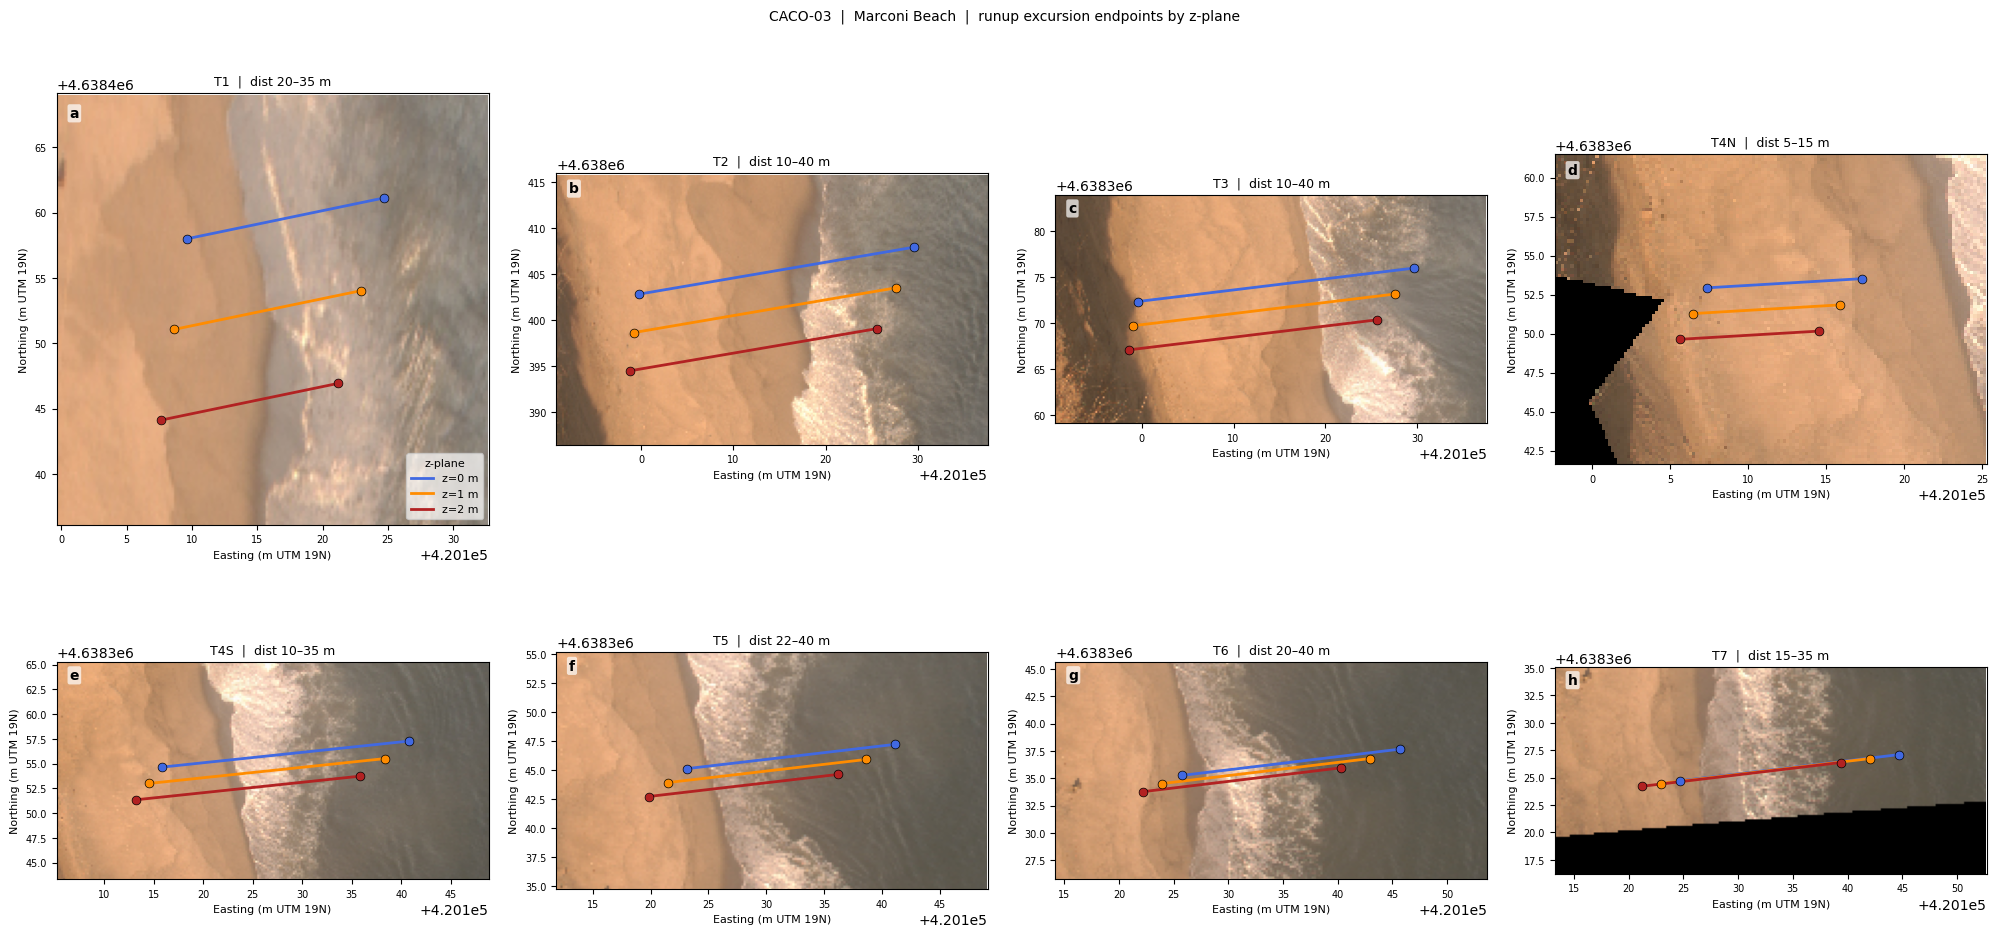

In [5]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
# Rectified ortho with endpoint segments colored by z-plane

import numpy as np
import matplotlib.pyplot as plt
import string

Z_COLORS     = {0.0: 'royalblue', 1.0: 'darkorange', 2.0: 'firebrick'}
Z_LABELS     = {0.0: 'z=0 m',     1.0: 'z=1 m',      2.0: 'z=2 m'}
ZOOM_PAD     = 8.0
panel_labels = string.ascii_lowercase

plot_names = [t[0] for t in TRANSECT_DEFS if t[0] in sens_named and t[0] in WINDOWS]
N_PLOT     = len(plot_names)
ncols      = 4
nrows      = int(np.ceil(N_PLOT / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.ravel()

for idx, name in enumerate(plot_names):
    ax = axes[idx]
    t  = sens_named[name]
    d_lo, d_hi = WINDOWS[name]

    E_z0    = t['E'][:, 0]
    dist_z0 = E_z0 - np.nanmin(E_z0)
    i_start = np.nanargmin(np.abs(dist_z0 - d_lo))
    i_end   = np.nanargmin(np.abs(dist_z0 - d_hi))

    all_E, all_N = [], []
    for z_idx, z in enumerate(Z_PLANES):
        E = t['E'][:, z_idx]
        N = t['N'][:, z_idx]
        all_E += [E[i_start], E[i_end]]
        all_N += [N[i_start], N[i_end]]

    x0 = min(all_E) - ZOOM_PAD;  x1 = max(all_E) + ZOOM_PAD
    y0 = min(all_N) - ZOOM_PAD;  y1 = max(all_N) + ZOOM_PAD

    ix0 = int(np.clip((x0 - xs[0]) / GRID_RES, 0, len(xs) - 1))
    ix1 = int(np.clip((x1 - xs[0]) / GRID_RES, 0, len(xs) - 1))
    iy0 = int(np.clip((y0 - ys[0]) / GRID_RES, 0, len(ys) - 1))
    iy1 = int(np.clip((y1 - ys[0]) / GRID_RES, 0, len(ys) - 1))
    crop = Ir_merged[iy0:iy1, ix0:ix1]
    ax.imshow(crop, origin='lower',
              extent=[xs[ix0], xs[ix1], ys[iy0], ys[iy1]],
              aspect='equal', zorder=0)

    for z_idx, z in enumerate(Z_PLANES):
        E  = t['E'][:, z_idx]
        N  = t['N'][:, z_idx]
        E0, N0 = E[i_start], N[i_start]
        E1, N1 = E[i_end],   N[i_end]
        col = Z_COLORS[z]
        ax.plot([E0, E1], [N0, N1], color=col, lw=2, zorder=5,
                label=Z_LABELS[z] if idx == 0 else None)
        ax.scatter([E0, E1], [N0, N1], color=col, s=40, zorder=6,
                   edgecolors='k', linewidths=0.5)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_xlabel('Easting (m UTM 19N)', fontsize=8)
    ax.set_ylabel('Northing (m UTM 19N)', fontsize=8)
    ax.set_title(f'{name}  |  dist {d_lo}\u2013{d_hi} m', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.text(0.03, 0.97, panel_labels[idx],
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

axes[0].legend(fontsize=8, framealpha=0.7, loc='lower right',
               title='z-plane', title_fontsize=8)
for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle('CACO-03  |  Marconi Beach  |  runup excursion endpoints by z-plane',
             fontsize=10, y=1.01)
plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig('sensitivity_endpoints_ortho.png', dpi=150, bbox_inches='tight')
plt.show()